https://www.kaggle.com/datasets/vivekattri/california-wildfire-damage-2014-feb2025

# Sobre o conjunto de dados
O Conjunto de Dados de Danos por Incêndios Florestais da Califórnia fornece uma visão geral abrangente dos incidentes de incêndios florestais na Califórnia na última década. Inclui dados sobre a extensão da destruição, como a área queimada (em acres), número de casas e empresas destruídas, veículos danificados, feridos, mortos e perdas financeiras estimadas (em milhões de dólares). O conjunto de dados também registra a data, o local e a causa de cada incêndio florestal, categorizando as causas como Raios, Atividade Humana ou Desconhecida.

Este conjunto de dados é valioso para analisar tendências de incêndios florestais, avaliar impactos financeiros e auxiliar na preparação para desastres e no planejamento de mitigação. Pode ser usado por pesquisadores, formuladores de políticas e analistas ambientais para obter insights sobre as consequências econômicas e ambientais dos incêndios florestais na Califórnia.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df_flo = pd.read_csv('California Wildfire Damage.csv')

In [2]:
df_flo

,Incident_ID,Date,Location,Area_Burned (Acres),Homes_Destroyed,Businesses_Destroyed,Vehicles_Damaged,Injuries,Fatalities,Estimated_Financial_Loss (Million $),Cause
0,INC1000,2020-11-22,Sonoma County,14048,763,474,235,70,19,2270.57,Lightning
1,INC1001,2021-09-23,Sonoma County,33667,1633,4,263,100,2,1381.14,Lightning
2,INC1002,2022-02-10,Shasta County,26394,915,291,31,50,6,2421.96,Human Activity
3,INC1003,2021-05-17,Sonoma County,20004,1220,128,34,28,0,3964.16,Unknown
4,INC1004,2021-09-22,Sonoma County,40320,794,469,147,0,15,1800.09,Unknown
...,...,...,...,...,...,...,...,...,...,...,...
95,INC1095,2018-01-16,Mendocino County,13112,1468,46,281,89,17,4008.58,Human Activity
96,INC1096,2022-07-07,Shasta County,39209,710,282,189,34,14,376.72,Human Activity
97,INC1097,2016-05-18,Shasta County,11863,702,9,40,100,1,1474.78,Human Activity
98,INC1098,2014-06-24,Napa Valley,1338,1619,262,293,94,3,3308.74,Human Activity


In [3]:
#Informações
df_flo.info()
df_flo.describe()
df_flo.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Incident_ID                           100 non-null    object 
 1   Date                                  100 non-null    object 
 2   Location                              100 non-null    object 
 3   Area_Burned (Acres)                   100 non-null    int64  
 4   Homes_Destroyed                       100 non-null    int64  
 5   Businesses_Destroyed                  100 non-null    int64  
 6   Vehicles_Damaged                      100 non-null    int64  
 7   Injuries                              100 non-null    int64  
 8   Fatalities                            100 non-null    int64  
 9   Estimated_Financial_Loss (Million $)  100 non-null    float64
 10  Cause                                 100 non-null    object 
dtypes: float64(1), int64

,Incident_ID,Date,Location,Area_Burned (Acres),Homes_Destroyed,Businesses_Destroyed,Vehicles_Damaged,Injuries,Fatalities,Estimated_Financial_Loss (Million $),Cause
0,INC1000,2020-11-22,Sonoma County,14048,763,474,235,70,19,2270.57,Lightning
1,INC1001,2021-09-23,Sonoma County,33667,1633,4,263,100,2,1381.14,Lightning
2,INC1002,2022-02-10,Shasta County,26394,915,291,31,50,6,2421.96,Human Activity
3,INC1003,2021-05-17,Sonoma County,20004,1220,128,34,28,0,3964.16,Unknown
4,INC1004,2021-09-22,Sonoma County,40320,794,469,147,0,15,1800.09,Unknown


In [4]:
#Valores Ausentes
df_flo.isna().sum()

Incident_ID                             0
Date                                    0
Location                                0
Area_Burned (Acres)                     0
Homes_Destroyed                         0
Businesses_Destroyed                    0
Vehicles_Damaged                        0
Injuries                                0
Fatalities                              0
Estimated_Financial_Loss (Million $)    0
Cause                                   0
dtype: int64

Contagem de incêndios por 'Causa'
Cause
Human Activity    38
Lightning         31
Unknown           31
Name: count, dtype: int64


C:\Users\Usuário\AppData\Local\Temp\ipykernel_6628\3001077409.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Cause', data=df_flo, palette='flare', order=df_flo['Cause'].value_counts().index)


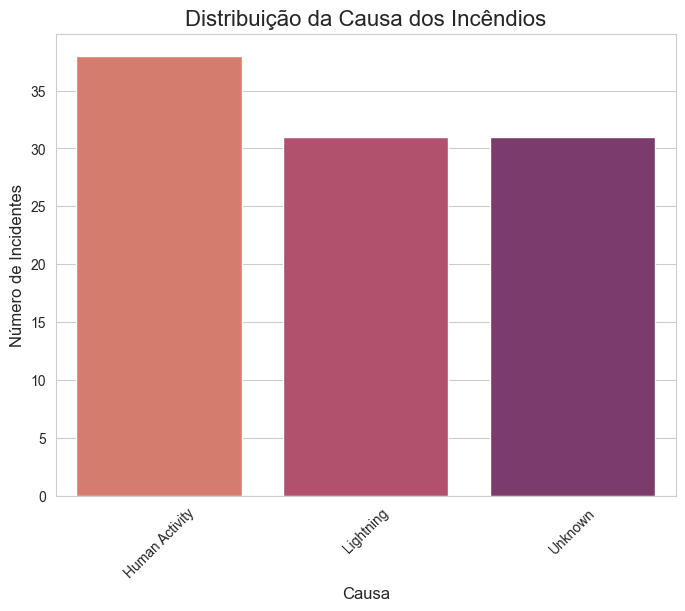

In [5]:
sns.set_style("whitegrid")
sns.set_palette("viridis")
#Variável 'Causa'
print("Contagem de incêndios por 'Causa'")
causas_contagem = df_flo['Cause'].value_counts()
print(causas_contagem)

plt.figure(figsize=(8, 6))
sns.countplot(x='Cause', data=df_flo, palette='flare', order=df_flo['Cause'].value_counts().index)
plt.title('Distribuição da Causa dos Incêndios', fontsize=16)
plt.xlabel('Causa', fontsize=12)
plt.ylabel('Número de Incidentes', fontsize=12)
plt.xticks(rotation=45)
plt.show()

Incêndios por "Atividade Humana" são frequentes e causam danos significativos.

In [6]:
#Variável 'Localização'
print("5 Localizações com mais incidentes")
print(df_flo['Location'].value_counts().head(5))

5 Localizações com mais incidentes
Location
Shasta County       14
Sonoma County       12
San Diego County    12
Butte County        11
Mendocino County    11
Name: count, dtype: int64


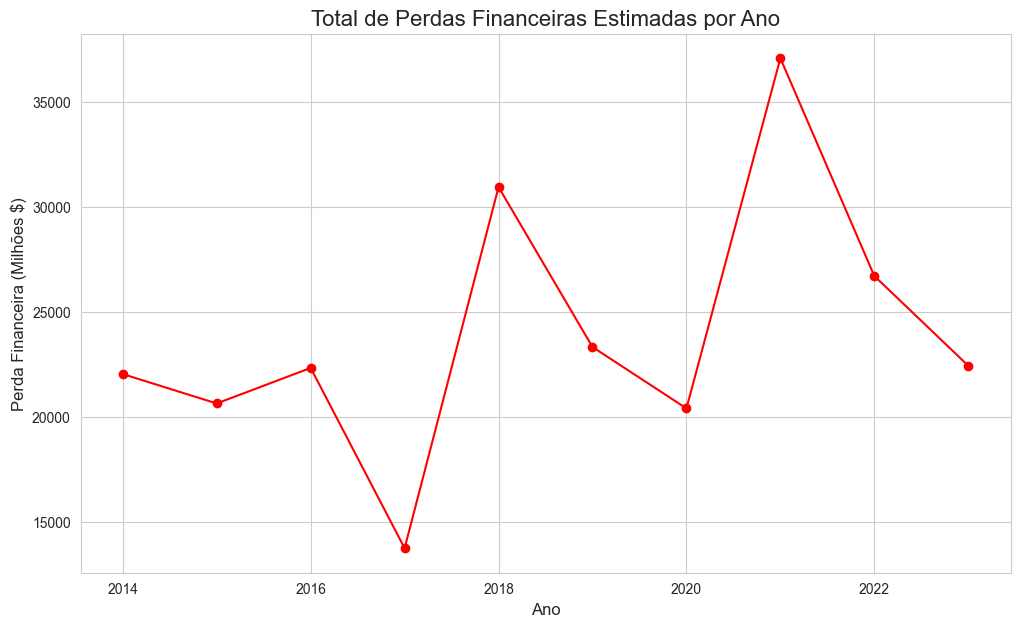

In [7]:
#Perdas financeiras ao longo do tempo
df_flo['Date'] = pd.to_datetime(df_flo['Date'])
df_flo['Year'] = df_flo['Date'].dt.year

perdas_por_ano = df_flo.groupby('Year')['Estimated_Financial_Loss (Million $)'].sum()

plt.figure(figsize=(12, 7))
perdas_por_ano.plot(kind='line', marker='o', color='red')
plt.title('Total de Perdas Financeiras Estimadas por Ano', fontsize=16)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Perda Financeira (Milhões $)', fontsize=12)
plt.grid(True)
plt.show()

O total de perdas financeiras estimadas variou significativamente ao longo dos anos. Uma queda drástica em 2017, seguida de um aumento acentuado em 2018. O maior pico de perdas ocorreu em 2021, com o valor mais alto registrado no período. Após 2021, houve um declínio nas perdas, mas os valores continuaram altos em comparação com o início da década.

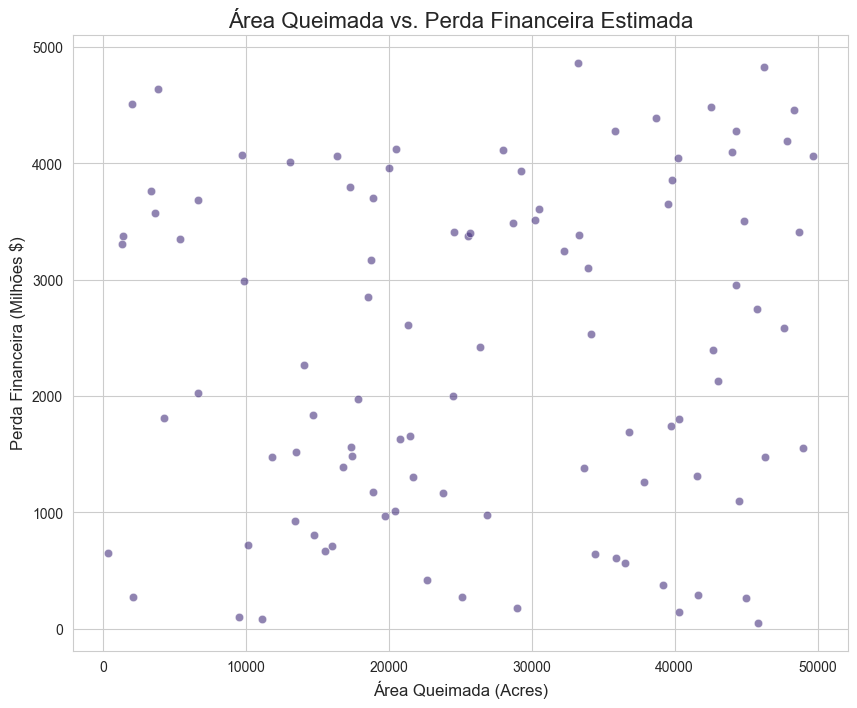

In [8]:
#Relação entre a área queimada e as perdas financeiras
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Area_Burned (Acres)', y='Estimated_Financial_Loss (Million $)', data=df_flo, alpha=0.6)
plt.title('Área Queimada vs. Perda Financeira Estimada', fontsize=16)
plt.xlabel('Área Queimada (Acres)', fontsize=12)
plt.ylabel('Perda Financeira (Milhões $)', fontsize=12)
plt.show()

Não há uma correlação clara entre a área queimada e a perda financeira. O tamanho da área queimada não é o único ou principal fator que determina o prejuízo financeiro. Outras variáveis, como o tipo de propriedade atingida (florestas, áreas residenciais ou indústrias) e o valor dos bens destruídos, podem ter um impacto maior no custo total.

In [9]:
#Tendências e Sazonalidade
df_flo['Date'] = pd.to_datetime(df_flo['Date'])
df_flo['Year'] = df_flo['Date'].dt.year
df_flo['Month'] = df_flo['Date'].dt.strftime('%B')

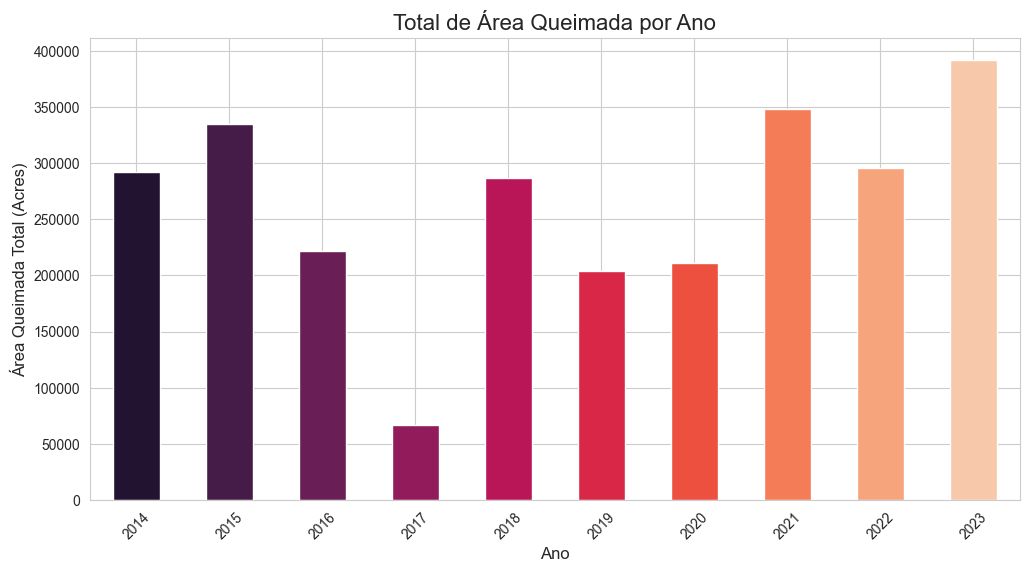

In [10]:
#Tendências de área queimada por ano
total_burned_by_year = df_flo.groupby('Year')['Area_Burned (Acres)'].sum()
plt.figure(figsize=(12, 6))
total_burned_by_year.plot(kind='bar', color=sns.color_palette("rocket", len(total_burned_by_year)))
plt.title('Total de Área Queimada por Ano', fontsize=16)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Área Queimada Total (Acres)', fontsize=12)
plt.xticks(rotation=45)
plt.show()

O ano de 2015 e 2023 se destacam com as maiores áreas queimadas, enquanto o ano de 2017 registrou o menor valor. Os anos de 2019 e 2020 também apresentaram valores relativamente baixos, seguidos por um aumento expressivo em 2021. A tendência geral demonstra uma flutuação considerável na área de floresta afetada anualmente.

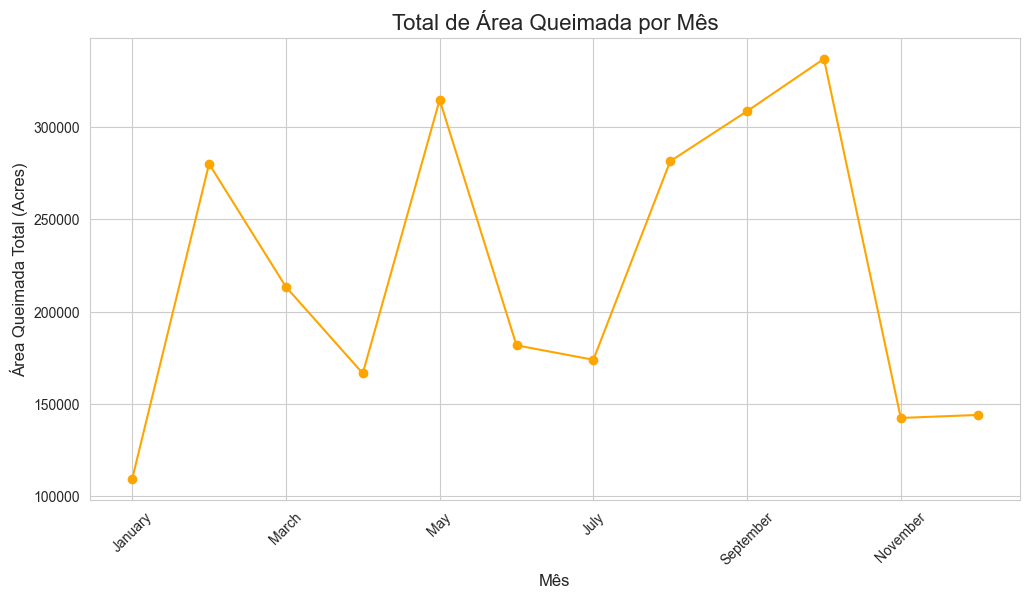

In [11]:
#Sazonalidade por mês
monthly_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
total_burned_by_month = df_flo.groupby('Month')['Area_Burned (Acres)'].sum().reindex(monthly_order)
plt.figure(figsize=(12, 6))
total_burned_by_month.plot(kind='line', marker='o', color='orange')
plt.title('Total de Área Queimada por Mês', fontsize=16)
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Área Queimada Total (Acres)', fontsize=12)
plt.xticks(rotation=45)
plt.show()

Maio e outubro, indicando que esses meses são os que têm mais incêndios em termos de área total. Há, também, quedas acentuadas em abril, junho e julho, com a área queimada se estabilizando em valores mais baixos nos meses de novembro e dezembro. Essa sazonalidade pode estar relacionada a fatores climáticos como estações secas ou períodos de ventos fortes.

In [12]:
#Impacto Financeiro e Demográfico
damage_by_location = df_flo.groupby('Location').agg({
    'Area_Burned (Acres)': 'sum',
    'Estimated_Financial_Loss (Million $)': 'sum',
    'Homes_Destroyed': 'sum'
}).sort_values(by='Estimated_Financial_Loss (Million $)', ascending=False)

print("Top 5 Localizações com Maior Perda Financeira")
print(damage_by_location.head(5))

Top 5 Localizações com Maior Perda Financeira
                  Area_Burned (Acres)  Estimated_Financial_Loss (Million $)  \
Location                                                                      
Shasta County                  355923                              37232.24   
Butte County                   321755                              36187.83   
Mendocino County               339912                              23864.77   
San Diego County               274239                              22914.56   
Sonoma County                  247739                              22501.82   

                  Homes_Destroyed  
Location                           
Shasta County               11855  
Butte County                10940  
Mendocino County            13166  
San Diego County             9201  
Sonoma County               10991  


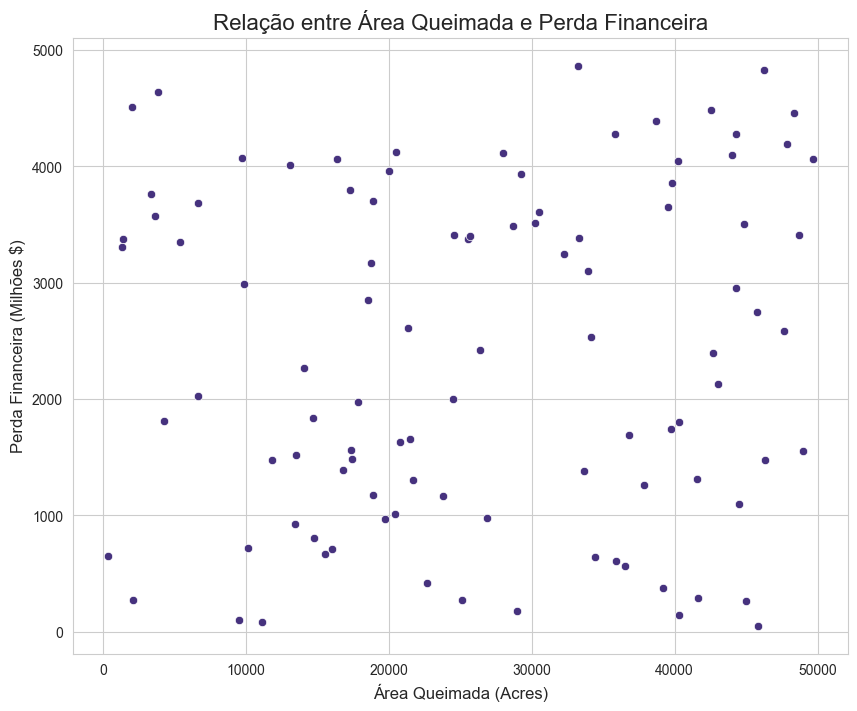

In [13]:
#Correlação entre a área queimada e a perda financeira
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Area_Burned (Acres)', y='Estimated_Financial_Loss (Million $)', data=df_flo)
plt.title('Relação entre Área Queimada e Perda Financeira', fontsize=16)
plt.xlabel('Área Queimada (Acres)', fontsize=12)
plt.ylabel('Perda Financeira (Milhões $)', fontsize=12)
plt.show()

Isso sugere que a extensão da área afetada pelo fogo não é o único ou o principal fator que determina o prejuízo financeiro. Outras variáveis, como a localização dos incêndios (por exemplo, em áreas residenciais de alto valor ou em florestas desabitadas) e os tipos de bens destruídos, provavelmente têm um impacto maior nas perdas econômicas.

Média de Danos por Causa do Incêndio
                Area_Burned (Acres)  Estimated_Financial_Loss (Million $)  \
Cause                                                                       
Human Activity         27573.763158                           2246.185263   
Lightning              24832.645161                           2579.400323   
Unknown                26952.612903                           2396.563871   

                Homes_Destroyed  
Cause                            
Human Activity       879.789474  
Lightning            981.354839  
Unknown              978.548387  


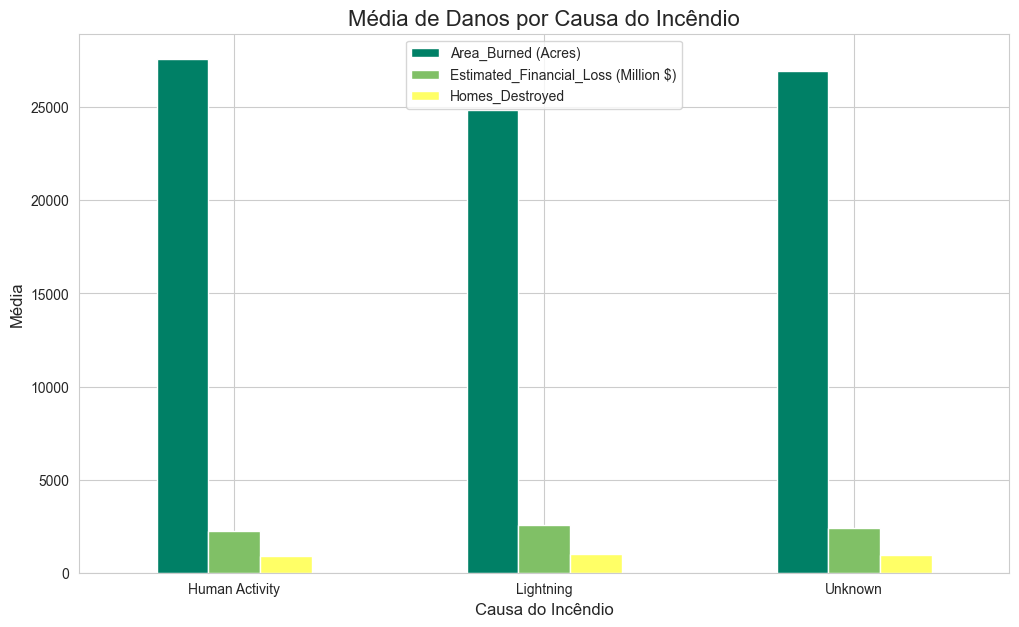

In [14]:
#Causa
causa_analise = df_flo.groupby('Cause').agg({
    'Area_Burned (Acres)': 'mean',
    'Estimated_Financial_Loss (Million $)': 'mean',
    'Homes_Destroyed': 'mean'
})

print("Média de Danos por Causa do Incêndio")
print(causa_analise)

causa_analise.plot(kind='bar', figsize=(12, 7), colormap='summer')
plt.title('Média de Danos por Causa do Incêndio', fontsize=16)
plt.xlabel('Causa do Incêndio', fontsize=12)
plt.ylabel('Média', fontsize=12)
plt.xticks(rotation=0)
plt.show()

A média de Área Queimada é significativamente maior do que a média de Perda Financeira e a média de Casas Destruídas. Embora a área queimada seja um indicador importante, ela nem sempre corresponde diretamente ao valor de bens e propriedades danificados, já que as médias de prejuízo financeiro e casas destruídas não variam muito entre as causas.

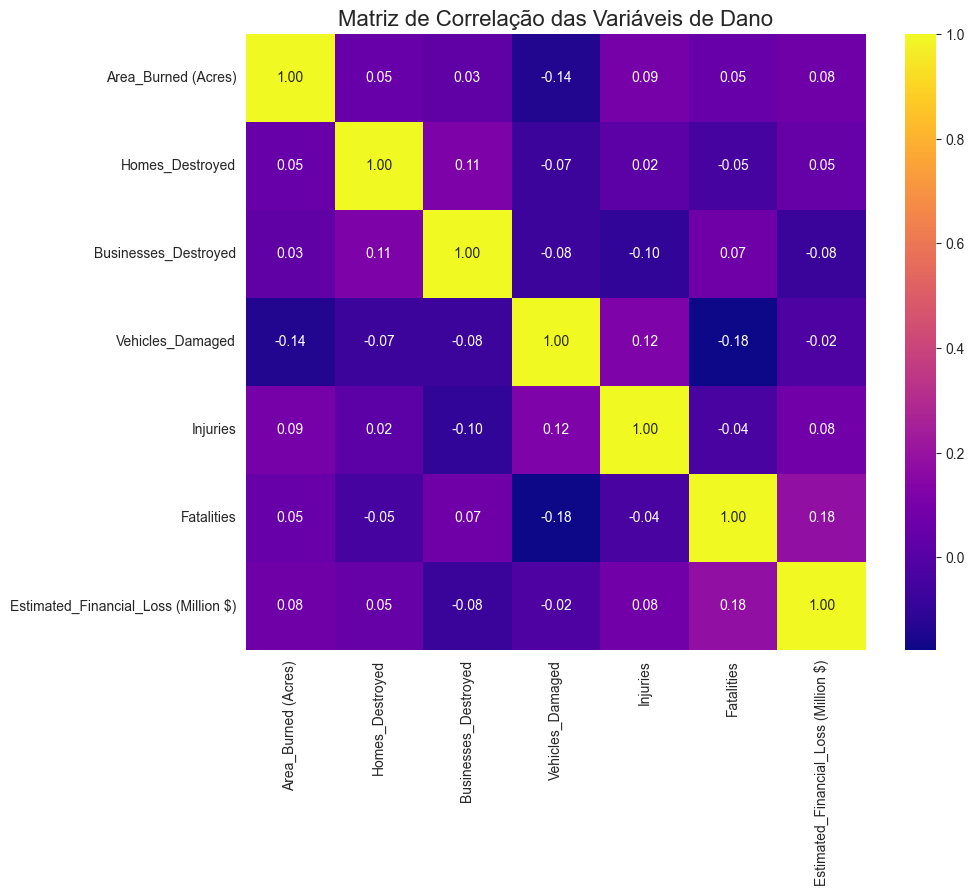

In [15]:
#Correlação Heatmap
numeric_cols = ['Area_Burned (Acres)', 'Homes_Destroyed', 'Businesses_Destroyed',
                'Vehicles_Damaged', 'Injuries', 'Fatalities',
                'Estimated_Financial_Loss (Million $)']

correlation_matrix = df_flo[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='plasma', fmt=".2f")
plt.title('Matriz de Correlação das Variáveis de Dano', fontsize=16)
plt.show()

O tamanho da área queimada não necessariamente determina o número de casas, negócios ou veículos danificados, nem o valor da perda financeira. Outros fatores, como a densidade populacional da área afetada ou a proximidade de infraestruturas, podem ser mais relevantes.

C:\Users\Usuário\AppData\Local\Temp\ipykernel_6628\3581589627.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cause', y='Homes_Destroyed', data=df_filtered, palette='Set1')


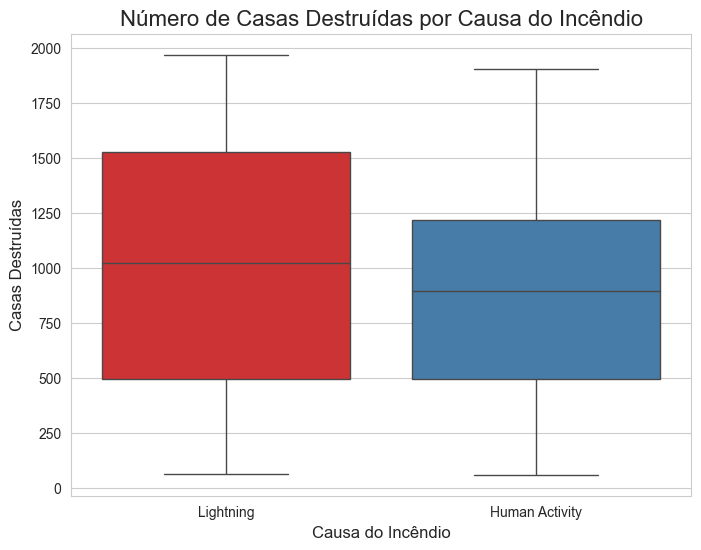

In [16]:
#Propensão (usando a causa)
causas = ['Human Activity', 'Lightning']
df_filtered = df_flo[df_flo['Cause'].isin(causas)]

plt.figure(figsize=(8, 6))
sns.boxplot(x='Cause', y='Homes_Destroyed', data=df_filtered, palette='Set1')
plt.title('Número de Casas Destruídas por Causa do Incêndio', fontsize=16)
plt.xlabel('Causa do Incêndio', fontsize=12)
plt.ylabel('Casas Destruídas', fontsize=12)
plt.show()

A mediana do número de casas destruídas é muito semelhante para ambas as causas. No entanto, a variação (representada pela altura da caixa e pelos "bigodes") para os incêndios causados por raios é maior, indicando que os dados são mais dispersos e que há mais casos com valores extremos. Em contrapartida, os casos de incêndios por atividade humana apresentam uma distribuição mais compacta.

C:\Users\Usuário\AppData\Local\Temp\ipykernel_6628\3574104072.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cause', y='Estimated_Financial_Loss (Million $)', data=df_filtered, palette='Set2')


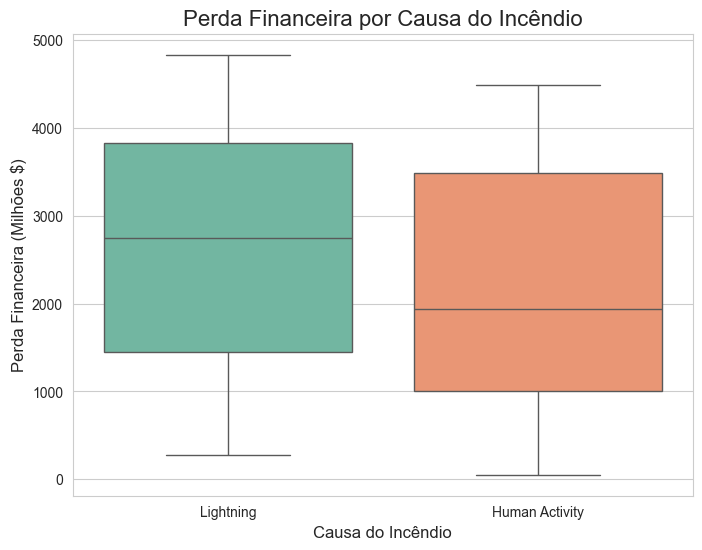

In [17]:
#Perdas financeiras médias
plt.figure(figsize=(8, 6))
sns.boxplot(x='Cause', y='Estimated_Financial_Loss (Million $)', data=df_filtered, palette='Set2')
plt.title('Perda Financeira por Causa do Incêndio', fontsize=16)
plt.xlabel('Causa do Incêndio', fontsize=12)
plt.ylabel('Perda Financeira (Milhões $)', fontsize=12)
plt.show()

A mediana das perdas financeiras para incêndios causados por raios seja ligeiramente maior que a mediana para incêndios causados por atividade humana, a variação nos valores é bastante semelhante para ambas as categorias. A causa do incêndio não é o principal fator que determina se a perda financeira será grande ou pequena.

In [18]:
#Modelagem
X = df_flo[['Area_Burned (Acres)', 'Homes_Destroyed', 'Businesses_Destroyed']]
y = df_flo['Estimated_Financial_Loss (Million $)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Avaliação do Modelo de Regressão Linear")
print(f"Erro Quadrático Médio (MSE): {mse:.2f}")
print(f"Pontuação R-quadrado (R²): {r2:.2f}")

Avaliação do Modelo de Regressão Linear
Erro Quadrático Médio (MSE): 2070653.62
Pontuação R-quadrado (R²): -0.06


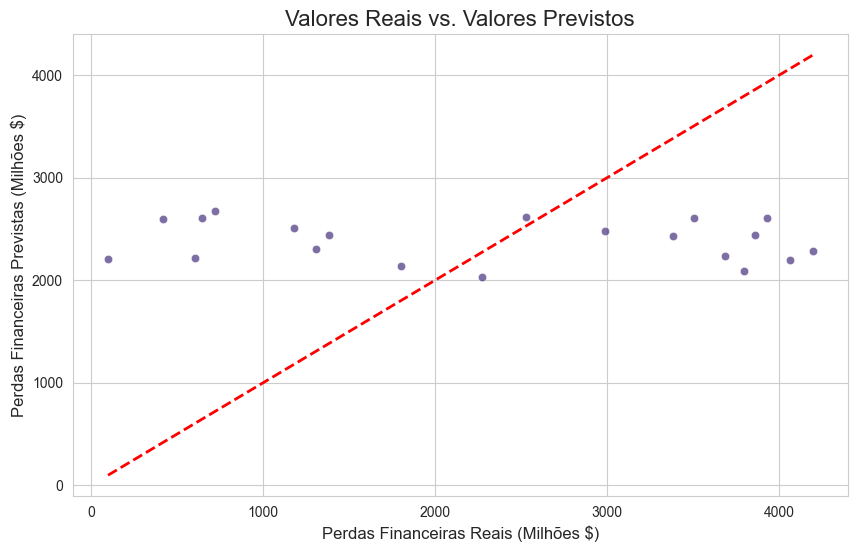

Coeficientes do Modelo
                      Coeficiente
Area_Burned (Acres)      0.003558
Homes_Destroyed          0.276302
Businesses_Destroyed    -1.291265


In [19]:
#Previsões vs. os valores reais
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)
plt.title('Valores Reais vs. Valores Previstos', fontsize=16)
plt.xlabel('Perdas Financeiras Reais (Milhões $)', fontsize=12)
plt.ylabel('Perdas Financeiras Previstas (Milhões $)', fontsize=12)
plt.show()

print("Coeficientes do Modelo")
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coeficiente'])
print(coefficients)

O modelo não consegue capturar a complexidade dos fatores que causam as grandes perdas financeiras.

In [20]:
from sklearn.ensemble import RandomForestRegressor
X = df_flo[['Area_Burned (Acres)', 'Homes_Destroyed', 'Businesses_Destroyed']]
y = df_flo['Estimated_Financial_Loss (Million $)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Avaliação do Modelo Random Forest")
print(f"Erro Quadrático Médio (MSE): {mse_rf:.2f}")
print(f"Pontuação R-quadrado (R²): {r2_rf:.2f}")

Avaliação do Modelo Random Forest
Erro Quadrático Médio (MSE): 2416697.04
Pontuação R-quadrado (R²): -0.24


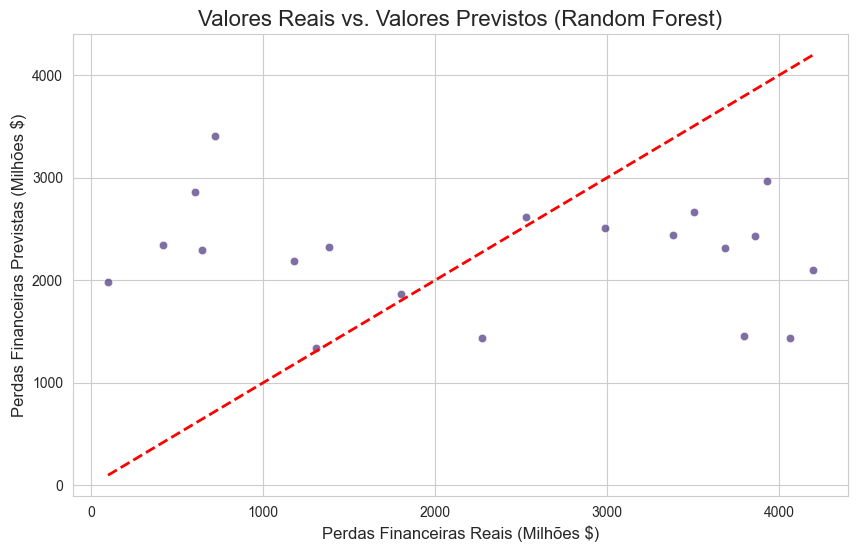

In [21]:
#Previsões vs. os valores reais
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)
plt.title('Valores Reais vs. Valores Previstos (Random Forest)', fontsize=16)
plt.xlabel('Perdas Financeiras Reais (Milhões $)', fontsize=12)
plt.ylabel('Perdas Financeiras Previstas (Milhões $)', fontsize=12)
plt.show()

A falta de proximidade dos pontos com a linha pontilhada demonstra que o modelo não é confiável para fazer previsões precisas das perdas financeiras.

Importância das Variáveis
                Feature  Importance
1       Homes_Destroyed    0.362256
0   Area_Burned (Acres)    0.336988
2  Businesses_Destroyed    0.300756


C:\Users\Usuário\AppData\Local\Temp\ipykernel_6628\3008562071.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='rocket')


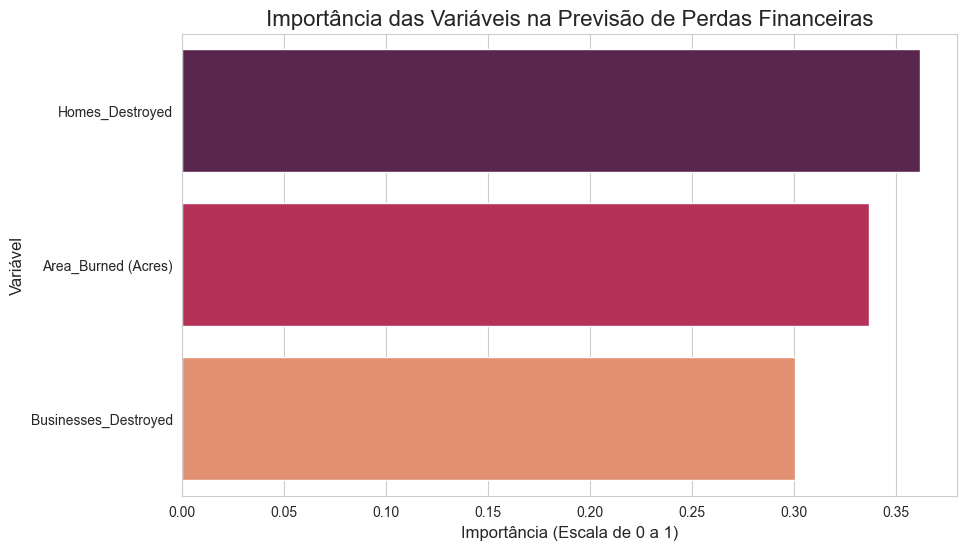

In [22]:
#Importância das Variáveis
feature_importances = model_rf.feature_importances_
features = X.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances}).sort_values(by='Importance', ascending=False)

print("Importância das Variáveis")
print(importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='rocket')
plt.title('Importância das Variáveis na Previsão de Perdas Financeiras', fontsize=16)
plt.xlabel('Importância (Escala de 0 a 1)', fontsize=12)
plt.ylabel('Variável', fontsize=12)
plt.show()

O número de casas destruídas (Homes_Destroyed) é a variável mais importante para prever as perdas financeiras. Embora a área queimada e o número de negócios destruídos também sejam relevantes, a destruição de residências tem o maior peso na estimativa dos custos.
Isso sugere que o valor das propriedades residenciais e os custos de reconstrução associados a elas são os principais impulsionadores das perdas financeiras totais em casos de incêndio.

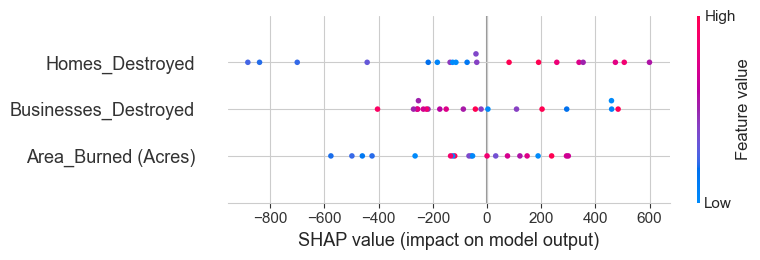

Simulação de Cenários Futuros


In [23]:
import shap
X = df_flo[['Area_Burned (Acres)', 'Homes_Destroyed', 'Businesses_Destroyed']]
y = df_flo['Estimated_Financial_Loss (Million $)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

explainer = shap.TreeExplainer(model_rf)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)
print("Simulação de Cenários Futuros")

O número de casas destruídas é a variável mais importante para prever perdas financeiras, e a área queimada tem um impacto menos previsível.

In [25]:
print("Simulação de Cenários Futuros")

#Cenário 1: Incêndio de Pequeno Porte
#Área: 500 acres, 50 casas, 10 empresas
scenario1 = pd.DataFrame([[500, 50, 10]], columns=X.columns)
prediction1 = model_rf.predict(scenario1)[0]
print(f"Previsão de perda financeira para um incêndio pequeno: ${prediction1:.2f} milhões")

#Cenário 2: Incêndio de Grande Porte
#Área: 20000 acres, 1500 casas, 200 empresas
scenario2 = pd.DataFrame([[20000, 1500, 200]], columns=X.columns)
prediction2 = model_rf.predict(scenario2)[0]
print(f"Previsão de perda financeira para um incêndio grande: ${prediction2:.2f} milhões")

#Cenário 3: Incêndio com Alto Dano à Propriedade (Área menor)
#Área: 5000 acres, 2000 casas, 500 empresas
scenario3 = pd.DataFrame([[5000, 2000, 500]], columns=X.columns)
prediction3 = model_rf.predict(scenario3)[0]
print(f"Previsão de perda financeira para um incêndio de alta destruição: ${prediction3:.2f} milhões")

Simulação de Cenários Futuros
Previsão de perda financeira para um incêndio pequeno: $1875.41 milhões
Previsão de perda financeira para um incêndio grande: $2661.85 milhões
Previsão de perda financeira para um incêndio de alta destruição: $2893.52 milhões


# Conclusão

A análise revela que os incêndios são um problema complexo. A atividade humana seja a principal causa de incidentes, ela não se correlaciona diretamente com a área queimada nem com as perdas financeiras.
As casas destruídas mostraram ser a variável mais importante na previsão de perdas financeiras, superando a área queimada e a destruição de negócios. Isso indica que a maior parte dos prejuízos econômicos está ligada a áreas residenciais.
O combate e a prevenção de incêndios devem focar não apenas em evitar a causa inicial, mas também em proteger áreas de alto valor, como regiões residenciais, já que elas têm o maior impacto nas perdas financeiras.

# Limitações

Fatores importantes, como as condições climáticas (velocidade do vento, umidade do ar), tipo de vegetação, relevo da área e tempo de resposta dos bombeiros, não foram considerados.
O modelo não é muito preciso para estimar as perdas financeiras. Isso pode ser por causa da falta de variáveis importantes ou por dados insuficientes.

# **Nathália Sorg**